In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week1/breast_cancer.csv')

# 확인
df


,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [2]:
df2=df.drop('label',axis=1)   # label 열을 제거한 데이터를 df2에 저장
df.head()                     # df의 상위 5개 행을 출력


,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
y=df2['worst compactness']    # worst compactness 열을 타깃값(y)으로 저장
y.value_counts()          # worst compactness 값들의 개수 확인
y

,worst compactness
0,0.66560
1,0.18660
2,0.42450
3,0.86630
4,0.20500
...,...
564,0.21130
565,0.19220
566,0.30940
567,0.86810


In [4]:
X=df2.drop('worst compactness',axis=1)  # worst compactness 열을 제외한 나머지 열을 입력값(X)으로 저장
X.head()                    # X의 상위 5개 행을 출력

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.2416,0.1860,0.2750,0.08902
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4504,0.2430,0.3613,0.08758
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,0.009208,14.91,26.50,98.87,567.7,0.2098,0.6869,0.2575,0.6638,0.17300
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.4000,0.1625,0.2364,0.07678


In [5]:
from sklearn.model_selection import train_test_split        # 데이터를 학습용/테스트용으로 나누는 함수 불러오기

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)    # 데이터를 75%를 학습용 25%를 테스트용으로 나눔 난수를 0으로하여 시드 고정


In [6]:
from sklearn.metrics import mean_squared_error      # 평균제곱오차(MSE)를 계산하는 함수 불러오기

In [7]:
from sklearn.linear_model import LinearRegression   # LinearRegression(회귀) 모델 불러오기

model = LinearRegression()      # LinearRegression 모델 생성
model.fit(X_train, y_train)      # 학습 데이터로 모델 학습
ly_preds = model.predict(X_test)    #결과 예측

print('평균제곱오차', mean_squared_error(ly_preds, y_test))   # sklearn 함수로 평균제곱오차(MSE) 출력

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)   # numpy로 평균제곱오차 계산

print('평균제곱오차', mse_np(ly_preds, y_test))                 # numpy로 계산한 평균제곱오차 출력

def mse(actual, predicted):                                       # 평균제곱오차를 구현해서 계산
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))                  # 직접 구현한 함수로 평균제곱오차 출력

평균제곱오차 0.0004937274846573661
평균제곱오차 0.0004937274846573661
평균제곱오차 0.0004937274846573658


In [8]:
from sklearn.tree import DecisionTreeRegressor             # DecisionTreeRegressor(회귀) 모델 불러오기

model = DecisionTreeRegressor(random_state=0)              # DecisionTreeRegressor(회귀) 모델 생성
model.fit(X_train, y_train)                               # 학습 데이터로 모델 학습
ly_preds = model.predict(X_test)                          #결과 예측

print('평균제곱오차', mean_squared_error(ly_preds, y_test))    # sklearn 함수로 평균제곱오차(MSE) 출력

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)   # numpy로 평균제곱오차 계산

print('평균제곱오차', mse_np(ly_preds, y_test))                 # numpy로 계산한 평균제곱오차 출력

def mse(actual, predicted):                                       # 평균제곱오차를 구현해서 계산
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))                  # 직접 구현한 함수로 평균제곱오차 출력

평균제곱오차 0.008368186449650351
평균제곱오차 0.008368186449650351
평균제곱오차 0.008368186449650348


In [9]:
from sklearn.ensemble import RandomForestRegressor    # RandomForestRegressor(회귀) 모델 불러오기

model = RandomForestRegressor(random_state=0)     #RandomForestRegressor 모델 생성
model.fit(X_train, y_train)      # 학습 데이터로 모델 학습
ly_preds = model.predict(X_test)    #결과 예측

print('평균제곱오차', mean_squared_error(ly_preds, y_test))   # sklearn 함수로 평균제곱오차(MSE) 출력

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)   # numpy로 평균제곱오차 계산

print('평균제곱오차', mse_np(ly_preds, y_test))                 # numpy로 계산한 평균제곱오차 출력

def mse(actual, predicted):                                       # 평균제곱오차를 구현해서 계산
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))                  # 직접 구현한 함수로 평균제곱오차 출력

평균제곱오차 0.002177954255623004
평균제곱오차 0.002177954255623004
평균제곱오차 0.002177954255623003


In [10]:
from sklearn.neighbors import KNeighborsRegressor

ly_knn = KNeighborsRegressor(n_neighbors=5)
ly_knn.fit(X_train, y_train)

pred_knn = ly_knn.predict(X_test)

print ("\n--- KNeighborsRegressor ---")

print('평균제곱오차', mean_squared_error(pred_knn, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(pred_knn, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(pred_knn, y_test))


--- KNeighborsRegressor ---
평균제곱오차 0.024308274172671326
평균제곱오차 0.024308274172671326
평균제곱오차 0.024308274172671333


In [11]:
# K값의 최적값을 찾기 위해 for문을 1~30까지 돌리고 그래프로 표현 Regression 에서는 MSE 값이 가장 작은값이 최적값


--- KNeighborsRegressor ---
최적의 k: 13
최소 평균제곱오차: 0.02169143109188563
평균제곱오차(sklearn) 0.02169143109188563
평균제곱오차(numpy) 0.02169143109188563
평균제곱오차(직접구현) 0.021691431091885618


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

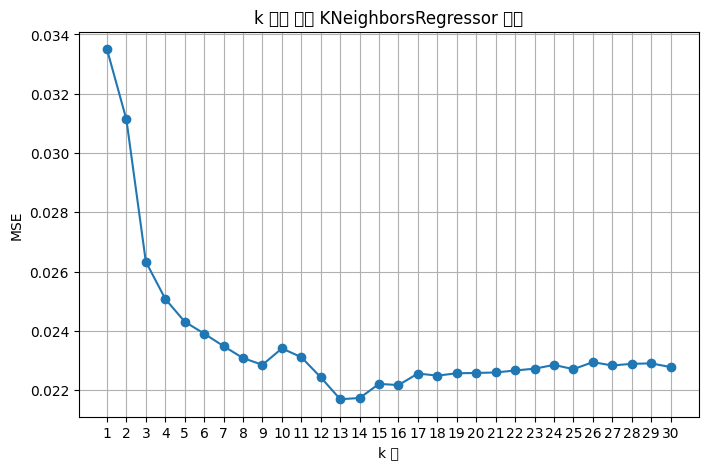

In [12]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

k_list = []
mse_list = []

#최적 k값 찾기
for k in range(1, 31):
    ly_knn = KNeighborsRegressor(n_neighbors=k)
    ly_knn.fit(X_train, y_train)

    pred_knn = ly_knn.predict(X_test)

    error = mean_squared_error(y_test, pred_knn)

    k_list.append(k)
    mse_list.append(error)

best_k = k_list[np.argmin(mse_list)]
best_mse = min(mse_list)

print("\n--- KNeighborsRegressor ---")
print("최적의 k:", best_k)
print("최소 평균제곱오차:", best_mse)

# 최적 k로 다시 예측
best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print('평균제곱오차(sklearn)', mean_squared_error(y_test, pred_knn))
print('평균제곱오차(numpy)', mse_np(y_test, pred_knn))
print('평균제곱오차(직접구현)', mse(y_test, pred_knn))

plt.figure(figsize=(8, 5))
plt.plot(k_list, mse_list, marker='o')
plt.xlabel("k 값")
plt.ylabel("MSE")
plt.title("k 값에 따른 KNeighborsRegressor 성능")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()